# POC 05 — dependence and causality from prototypes

POC_04 settled what the prototypes carry: with the weekday·hour key, per client rather than
FINCH centroids, and from a model that has seen the regime, the decoded prototypes recover the
data's similarity ordering on ~85% of pairs. This notebook takes the next step and asks whether
they carry **dependence** and **direction**, under four stages that each have their own
precondition and their own null.

* **Stage 0 — preconditions.** What this world can support, measured before anything is fitted:
  phase spans and blocks, the chain's estimation budget, channel balance, and whether there is
  active storage exchange at all (the gate on any window-scale lag arm).
* **Stages 1–2 — one frozen ruler.** Every trajectory is built from a single model applied to
  every window, so the trajectory is the world moving and not the training curve.
* **Stage 3 — transfer gain.** Does client *c*'s past predict client *d*'s next block, beyond
  *d*'s own past and the others' present? Out of sample, with a dimension-matched null.
* **Stage 4 — quantisation and the chain.** The occupancy fingerprint, the transition matrix,
  and MI / transfer entropy in symbol space, each reported with its plug-in bias.
* **Stage 5 — partial correlation.** What survives conditioning on the other clients — the
  instantaneous half, which is where hydraulic coupling lives (lag 0).

**What is ground truth and what is not.** `gt_*`, the drift schedule and the network's boundary
structure are used for SCORING only and never enter an estimator, per the architecture doc's
invariant 4. The mixture labels from the probe stack are a reference, not truth.

**Nothing here is validated on synthetic data.** `fedwater_lab.selfcheck` runs the same
estimators against saved runs and files the verdicts; §9 shows its register.

## 0. Setup

**One OpenMP runtime per process.** On Windows, the pip torch wheel ships its own
`libiomp5md.dll`, and a conda MKL NumPy loads a second one the first time its *multithreaded*
code runs (its FFT, its BLAS). The second copy aborts the kernel with OMP Error #15, and which
NumPy call triggers it depends on MKL's internals, so replacing individual calls only moves the
crash. `MKL_THREADING_LAYER=SEQUENTIAL` makes MKL use its sequential layer, which loads no
OpenMP runtime at all. It must be set **before NumPy is imported**, so it is the first line
below. Single-threaded MKL costs nothing at these sizes (a few clients × a few dozen blocks).

The check at the end of the cell deliberately starts torch's runtime and then makes one MKL
BLAS call. If the switch did not take effect, the kernel dies **here, within seconds**, rather
than 20 s into §3. It then records

$$n_{\text{iomp}} = \#\{\text{loaded runtimes with prefix } \texttt{libiomp}\}, \qquad
\text{pass} \iff n_{\text{iomp}} \le 1,$$

together with MKL's reported threading layer, which should read `sequential`.
**Do not** use `KMP_DUPLICATE_LIB_OK=TRUE`: Intel documents that it can silently produce
incorrect results.

In [1]:
import os
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"   # BEFORE numpy: see the note above
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))   # silences joblib's core-count warning on Windows

import sys, pathlib, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
LAB_DIR = (REPO / "notebooks" / "fedwater_lab_refactor") if REPO else pathlib.Path.cwd()
for p in ([REPO / "src"] if REPO else []) + [LAB_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab import (precond as PC, traj as TJ, transfer as TR, chain as CH,
                          partialdep as PD, grid as GD, selfcheck as SC)
from fedwater_lab.checks import Register, openmp_runtimes

REG = Register("POC_05")
pd.set_option("display.width", 200)
plt.ioff()

# ---- where the runs are. Either a live Store, or a directory of saved runs.
STORE_ROOT = LAB_DIR / "lab_sandbox"           # <- the live sandbox
RUNS_DIR   = STORE_ROOT / "runs"               # <- or an exported runs/ folder

HAVE_REPO = REPO is not None
print("repo:", REPO, "| lab:", LAB_DIR)

# ---- the OpenMP check: torch's runtime first, then one MKL BLAS call.
try:
    import torch
    torch.get_num_threads()
    _ = torch.ones(256, 256) @ torch.ones(256, 256)
except ImportError:
    torch = None
_ = np.ones((256, 256)) @ np.ones((256, 256))        # dies HERE if the fix did not take
RUNTIMES = openmp_runtimes()
display(RUNTIMES[["user_api", "internal_api", "prefix", "threading_layer"]])
for fp in RUNTIMES.loc[RUNTIMES["prefix"] == "libiomp", "filepath"]:
    print("libiomp loaded from:", fp)               # full path: which package brought it
N_IOMP = int((RUNTIMES["prefix"] == "libiomp").sum())
MKL_LAYER = RUNTIMES.loc[RUNTIMES["internal_api"] == "mkl", "threading_layer"].tolist()
REG.expect("env", "Intel OpenMP runtimes loaded", N_IOMP, N_IOMP <= 1,
           "two = torch's + MKL's: the OMP Error #15 condition")
REG.report("env", "MKL threading layer", MKL_LAYER or "no MKL in this process",
           "should read 'sequential'")

repo: c:\Users\arthu\USPy\10_Mestrado\fedWater | lab: c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\fedwater_lab_refactor


,user_api,internal_api,prefix,threading_layer
0,blas,mkl,mkl_rt,sequential
1,openmp,openmp,libiomp,None
2,openmp,openmp,libiomp,None


libiomp loaded from: C:\Users\arthu\anaconda3\envs\TsLeaks\Lib\site-packages\torch\lib\libiomp5md.dll
libiomp loaded from: C:\Users\arthu\anaconda3\envs\TsLeaks\Lib\site-packages\torch\lib\libiompstubs5md.dll


Register('POC_05', rows=2, checks=1, failed=1, gates=0, closed=0)

## 1. The grid, read through the Store

**One lookup, not two.** `aligned.analyse` → `runner.run_cell` is a cache read only when
`Store.exists` finds `<root>/runs/<world_hash>/<run_key>/meta.json`; on a miss it **trains**. So
the index here is built from the same Store the analysis will read, and every run is checked
with `grid.locate` — a run the Store cannot see is reported now, not discovered as a retrain in
§3. (A flat export, `runs/<run_key>/`, is readable by `scan` but invisible to the Store.)

`grid.scan` expands the axes that live only in `spec.json`; `comparable_blocks` marks which cells
may be **differenced** — same world, sensor selection, geometry, transform and scaler. Across those
you may rank, not subtract.

In [2]:
store = None
if HAVE_REPO:
    from fedwater_lab.store import Store
    store = Store(STORE_ROOT)                      # the ONLY place runs are read from
    IDX = GD.scan(store.root / "runs")
    IDX["store_readable"] = [GD.locate(store, r.world_hash, r.run_key)["exists"]
                             for r in IDX.itertuples(index=False)]
    bad = IDX[~IDX["store_readable"]]
    if len(bad):
        display(bad[["run_key", "label", "dir"]])
        raise FileNotFoundError(
            f"{len(bad)} run(s) are not at runs/<world_hash>/<run_key>/ under "
            f"{store.root}; analyse() would RETRAIN them. Move them first.")
else:
    IDX = GD.scan(RUNS_DIR)                        # world-free path: latents only

IDX = GD.comparable_blocks(IDX)
display(IDX[["run_key", "label", "schedule", "proto_weight", "spec_term",
             "rounds", "cmp_block"]])
display(GD.coverage(IDX))

# The cell every detailed section reads: the frozen ruler is a commissioning model.
# Pinned by key: `.iloc[-1]` of a 42-run index depends on directory order.
FOCUS_KEY = "ec97004a74de"
FOCUS = IDX[IDX["run_key"] == FOCUS_KEY].iloc[0]
print("focus:", FOCUS["label"], f"[{FOCUS['run_key']}]")
REG.report("grid", "cells pulled", len(IDX),
           f"{IDX['cmp_block'].nunique()} comparability block(s)")

,run_key,label,schedule,proto_weight,spec_term,rounds,cmp_block
0,2f3aba5dcac9,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,commissioning,0.0,0.0,712,0
1,57aa26c2408f,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,streaming,0.1,1.0,30,0
2,694733f16841,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,all,0.1,1.0,30,0
3,8241f2e9ba64,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,all,0.0,0.0,30,0
4,d11b40a20d21,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,streaming,0.0,0.0,30,0
5,da72c9bbae27,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,commissioning,0.1,1.0,712,0
6,1dced6f2762d,fmp~b02f4f__none__minmax_ref__a3w84s12__u30r5s0,all,NaN,NaN,5,1
7,fe4d4a60301a,fpmp__none__minmax_ref__a3w84s12__u30r5s0,all,NaN,NaN,5,2
8,028ca9bf44b3,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,all,0.1,0.0,30,3
9,0f14e551356d,fmp__none__minmax_ref__a3w84s4__u30r30e5s0__Lp0,all,0.0,0.0,30,4


,axis,levels,counts,min_cells,estimable
0,schedule,3,"{'all': 24, 'commissioning': 9, 'streaming': 9}",9,True
1,schedule_months,5,"{'None': 24, '0-11': 9, 'B6x129': 4, 'B6x24': ...",2,True
2,loss,6,"{'Lp0': 15, 'Lp0.1-s1': 13, 'upstream': 8, 'Ls...",1,False
3,proto_weight,4,"{'0.0': 15, '0.1': 15, 'nan': 8, '1.0': 4}",4,True
4,spec_term,3,"{'0.0': 18, '1.0': 16, 'nan': 8}",8,True
5,diff_term,3,"{'0.0': 32, 'nan': 8, '1.0': 2}",2,True
6,var_term,3,"{'0.0': 33, 'nan': 8, '1.0': 1}",1,False
7,scaling,1,{'minmax_ref': 42},42,False
8,transform,1,{'none': 42},42,False
9,orient,2,"{'True': 30, 'False': 12}",12,True


focus: fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0__Lp0.1-s1__C0-11 [ec97004a74de]


Register('POC_05', rows=3, checks=1, failed=1, gates=0, closed=0)

## 2. Stage 0 — preconditions

Three things decide what is estimable here, and all three are properties of the WORLD:

* **blocks in transition** — the rolling gain needs blocks inside the ramp to localise anything;
* **the chain budget** — plug-in MI bias is $\mathrm{df}/2N$ nats with $\mathrm{df}=(k-1)^2$ for
  $I(s_c;s_d)$ and $k(k-1)^2$ for the transfer entropy, so $k$ and the horizon decide each other;
* **active storage exchange** — per tank, the share of steps with non-zero net flux, the sign
  changes per day, and the share of delivered volume passing through storage. If the median tank
  does not clear the thresholds, the **window-scale lag arm stays closed on this world** and the
  only directional mechanism left is month-scale drift propagation. The thresholds are arguments
  here, not hidden constants.

With no repo on the path the world cannot be opened, and the census falls back to the run's own
`meta.json` (which carries the phases); the storage gate is then reported as unavailable rather
than guessed.

In [3]:
BLOCK_MONTHS, BIN_H, PERIOD_H, K_STATES = 3, 24, 168, 3

world = None
if HAVE_REPO:
    from fedwater_lab.worlds import load_world
    wp = FOCUS.get("world_path")
    if wp and pathlib.Path(wp).exists():
        world = load_world(wp)
        display(world.summary().to_frame().T)

if world is not None:
    from fedwater_lab.specs import POC, Geometry
    from fedwater_lab import data as D, recon as RC, aligned as AL
    from fedwater_lab.store import _spec_from_dict
    SPEC = _spec_from_dict(json.loads((pathlib.Path(FOCUS["dir"]) / "spec.json").read_text()))
    FW, _, FL = D.build_windows(world, SPEC, cache=D.CACHE)
    CHANNELS = RC.channel_table(world, FW)
    S0 = PC.stage0(world, CHANNELS, block_months=BLOCK_MONTHS,
                   n_classes=int(168 // BIN_H), k=K_STATES,
                   min_blocks_transition=8, reg=REG)
    display(S0["phases"]); display(S0["budget"])
    if S0["storage"]["available"]:
        display(S0["storage"]["per_tank"].round(4))
    print("lag arm (window-scale):", "OPEN" if S0["lag_arm"] else "CLOSED",
          "| active tanks:", S0["storage"]["verdict"].get("active_tanks", []) if S0["storage"]["available"] else "n/a")
else:
    meta = json.loads((pathlib.Path(FOCUS["dir"]) / "meta.json").read_text())
    print("no world on the path — census from the run's own meta.json")
    print("phases:", meta["phases"], "| drift:", meta["drift_district"])
    REG.report("stage0", "world", "unavailable",
               "storage-exchange gate not measured: the lag arm stays closed")

,sim_hash,tag,network,districting,partition_id,placement_source,n_months,resolution_h,steps_day,clients,...,n_mixed,drift_district,warmup_months,first_switch,last_switch,ramp_days,init_months,final_months,regime_init,regime_final
0,f335b2cfad67,District_A__LR_LR_LC_LI__baseline,ky72,spectral,29fddafe,dynamic,70,1,24,4,...,16,District_A,12,12,52,7.0,0..11,53..69,LR_LR_LC_LI,LI_LR_LC_LI


,phase,m_lo,m_hi,months,blocks,last_block_months
0,init,0,11,12,4,3
1,transition,12,52,41,14,2
2,final,53,69,17,6,2


,quantity,value,floor,ok
0,transitions available (n_blocks x n_classes),168.000000,NaN,NaN
1,transitions needed for P-hat (c_cell=10 k^2),168.000000,90.0,True
2,MI plug-in bias (nats),0.011905,NaN,NaN
3,TE plug-in bias (nats),0.035714,NaN,NaN


,tank,n_links,active_frac,flips_day,throughput,net_mean,net_std,active
0,T-1,1,0.0009,0.0000,0.0003,0.0278,1.0433,False
1,T-2,2,0.0010,0.0041,0.0002,0.0084,1.2232,False
2,T-3,1,0.9756,3.1194,0.2991,-0.1385,30.6830,True


lag arm (window-scale): OPEN | active tanks: ['T-3']


## 3. Stages 1–2 — the frozen ruler and $\varphi$

Two arms, and they answer different questions:

* **decoded** — `aligned.build` under one model, features of $\mathrm{dec}(p[c,g])$. This is the
  arm POC_04 showed carries the similarity ordering, and it needs the world and the decoder.
* **raw latent** — the group-mean latent projected on a PCA basis **fitted on init and frozen**.
  This is the artifact the protocol exchanges verbatim; POC_04 found its cosine near chance
  outside init, so treat it as the cheap arm, not the answer.

Either way the ruler is frozen: `prototype_history` records each month's prototype at the round
it was produced, so a trajectory read straight off it mixes world change with training progress.
`ruler_stability` decodes the history with the SAME decoder and correlates the two — that number
says how much of the naive trajectory was the model moving.

The contract check is the one that matters most: the per-month mean of `latent_trajectories`
must equal the run's own `post_fedavg_full` prototype. It does, exactly (`max |Δ| = 0`), which
is what makes this trajectory the federated object rather than something adjacent to it.

**The guard.** `grid.assert_cached` recomputes the run key from the world and the spec and
refuses to call `analyse` unless it is a cache hit, naming which of the two possible causes it
is: a different key (the sensor selection resolved to a different `sensor_hash`) or the right key
in the wrong directory. An analysis notebook must never train.

In [4]:
import threading
from contextlib import contextmanager
from tqdm.auto import tqdm

TIMES = {}

@contextmanager
def live_steps(total, desc):
    """A step bar whose elapsed clock keeps ticking during long blocking calls
    (a background thread redraws it every second), with each step's duration
    recorded in TIMES."""
    bar = tqdm(total=total, desc=desc, bar_format="{desc} {n}/{total} |{bar}| {elapsed}")
    stop = threading.Event()
    def tick():
        while not stop.wait(1.0):
            bar.refresh()
    t = threading.Thread(target=tick, daemon=True)
    t.start()
    def step(label, fn):
        bar.set_description_str(f"{desc} · {label}", refresh=True)
        t0 = time.time()
        out = fn()
        TIMES[label] = round(time.time() - t0, 1)
        bar.update(1)
        return out
    try:
        yield step
    finally:
        stop.set(); t.join()
        bar.set_description_str(f"{desc} · done", refresh=True)
        bar.close()

FEATS = TJ.FeatureSpec(feats=("lvl", "amp", "p24"), band_width=1)
ARMS = {}

if world is not None:
    ALIGN = AL.Alignment(period_h=PERIOD_H, bin_h=BIN_H, block=BLOCK_MONTHS)
    with live_steps(9, "§3") as step:
        GUARD = step("cache guard",
                     lambda: GD.assert_cached(store, world, SPEC, expected_key=FOCUS["run_key"]))
        OUT = step("analyse (~20 s)",
                   lambda: AL.analyse(world, SPEC, ALIGN, store=store, server=False, n_perm=99))
        assert OUT["res"].get("cache_hit"), "analyse() trained -- this must never happen here"
        RUN = OUT["run"]
        COV = step("coverage", lambda: AL.coverage(RUN.wt, ALIGN))
        for arm in ("pure", "mixed", None):
            name = arm or "all"
            ARMS[name] = step(f"trajectory [{name}]",
                              lambda arm=arm: TJ.trajectory(RUN, CHANNELS, arm, FEATS))
        PHI_DEM = ARMS["pure"]["phi_demand"]          # the centralized ceiling
        REC = step("recoverability",
                   lambda: TJ.recoverability(ARMS["pure"]["phi"], PHI_DEM))
        HIST = step("history_features",
                    lambda: TJ.history_features(OUT["res"], OUT["model"], world, CHANNELS,
                                                "pure", FEATS, agg_h=RUN.agg_h))
        RST = step("ruler_stability",
                   lambda: TJ.ruler_stability(ARMS["pure"]["phi"], HIST, ARMS["pure"]["blocks"]))
    print(GUARD)
    display(COV.head())
    display(REC.round(3))
    display(RST.round(3))
else:
    with live_steps(3, "§3 (latent)") as step:
        T = step("load tables", lambda: GD.load_tables(FOCUS))
        WT = step("latent windows",
                  lambda: TJ.latent_windows(T["latent_trajectories"], T["fl"]["preprocessing"],
                                            T["meta"]["phases"], BLOCK_MONTHS, PERIOD_H, BIN_H))
        ARMS["latent"], ARMS["latent_pooled"] = step("latent phi (2 bases)",
            lambda: (TJ.latent_phi(WT, n_comp=2, basis="per_client"),
                     TJ.latent_phi(WT, n_comp=2, basis="pooled")))
    print("blocks per phase:", WT.groupby("phase")["bid"].nunique().to_dict(),
          "| cycle classes:", WT["cycle_pos"].nunique())

print("step times (s):", TIMES)
ARM = "pure" if world is not None else "latent"
# Stages 3-5 pool the calendar classes as replicates, so they need the CLASS-level phi.
# The block-level phi (classes averaged + weekend contrasts) is for block reading only.
PHI = ARMS[ARM]["phi_class"] if world is not None else ARMS[ARM]["phi"]
PHI_BLOCK = ARMS[ARM]["phi"]
FEAT_COLS = tuple(TJ.feature_cols(PHI))
print("arm:", ARM, "| features:", FEAT_COLS, "| blocks:", PHI["bid"].nunique(),
      "| classes (replicates):", PHI["cycle_pos"].nunique() if "cycle_pos" in PHI else 1)

§3 0/9 |          | 00:00

{'run_key': 'ec97004a74de', 'sensor_hash': '86cff5b9', 'expected': 'C:\\Users\\arthu\\USPy\\10_Mestrado\\fedWater\\notebooks\\fedwater_lab_refactor\\lab_sandbox\\runs\\f335b2cfad67\\ec97004a74de\\meta.json', 'exists': True, 'found_elsewhere': []}


,gid,block_label,phase,cycle,n_min,n_max,n_clients
0,0,init m0-2,init,d0·00h,6,6,4
1,1,init m0-2,init,d1·00h,6,6,4
2,2,init m0-2,init,d2·00h,6,6,4
3,3,init m0-2,init,d3·00h,6,6,4
4,4,init m0-2,init,d4·00h,8,8,4


,client,feature,n,r_model_demand
0,District_A,lvl,24,0.937
1,District_A,amp,24,0.776
2,District_A,p24,24,0.857
3,District_A,lvl_we,24,0.945
4,District_A,amp_we,24,-0.796
5,District_B,lvl,24,-0.490
6,District_B,amp,24,0.339
7,District_B,p24,24,-0.331
8,District_B,lvl_we,24,0.043
9,District_B,amp_we,24,0.111


,client,feature,n,r_frozen_moving
0,District_A,lvl,4,0.015
1,District_A,amp,4,0.622
2,District_A,p24,4,0.046
3,District_B,lvl,4,-0.255
4,District_B,amp,4,0.160
5,District_B,p24,4,0.496
6,District_C,lvl,4,-0.979
7,District_C,amp,4,0.988
8,District_C,p24,4,0.964
9,District_D,lvl,4,0.128


step times (s): {'cache guard': 0.0, 'analyse (~20 s)': 7.2, 'coverage': 0.0, 'trajectory [pure]': 0.4, 'trajectory [mixed]': 0.4, 'trajectory [all]': 0.5, 'recoverability': 0.0, 'history_features': 0.0, 'ruler_stability': 0.0}
arm: pure | features: ('lvl', 'amp', 'p24') | blocks: 24 | classes (replicates): 7


## 4. Stage 3 — transfer gain

Per target $d$, source $c$, lag $p$:

$$\text{restricted}:\;\varphi_d[b]\sim\varphi_d[b\!-\!1..b\!-\!p]+\mathrm{ctrl}[b]+\mathrm{ctrl}[b\!-\!1..b\!-\!p]
\qquad \text{full}:\;+\,\varphi_c[b\!-\!1..b\!-\!p]$$

$$G_{c\to d}=1-\frac{\mathrm{SSE}_{\text{full}}}{\mathrm{SSE}_{\text{restricted}}}$$

fitted on blocks strictly earlier than $b$ and scored on $b$, pooled over the calendar classes as
replicates. The control is the clients other than $c$ and $d$, entering at the **concurrent**
block as well as at lags: with lagged controls only, a shared driver makes every client one more
noisy measurement of it, so *any* added client improves the forecast and $G$ becomes a statement
about measurement count rather than mechanism.

Three readings, none optional:

* `r2_restricted` is the AR-R² diagnostic. If $G$ tracks it across targets, the asymmetry is a
  self-predictability artifact **on this world** — measured here rather than inherited from
  Graeme.
* `capacity_null` refits with a dimension-matched surrogate source (whole blocks permuted,
  replicates attached). Read $G$ against that null, never against 0.
* time reversal: propagation weakens or inverts, a variance artifact is symmetric.

target,District_A,District_B,District_C,District_D
source,,,,
District_A,NaN,-0.044,-0.080,-0.400
District_B,0.132,NaN,0.144,-0.291
District_C,-0.082,0.039,NaN,0.035
District_D,-0.075,0.061,0.046,NaN


,client_a,client_b,G_a_to_b,G_b_to_a,asym,direction
0,District_A,District_B,-0.044,0.132,-0.176,District_B->District_A
1,District_A,District_C,-0.080,-0.082,0.001,District_A->District_C
2,District_A,District_D,-0.400,-0.075,-0.325,District_D->District_A
3,District_B,District_C,0.144,0.039,0.105,District_B->District_C
4,District_B,District_D,-0.291,0.061,-0.353,District_D->District_B
5,District_C,District_D,0.035,0.046,-0.011,District_D->District_C


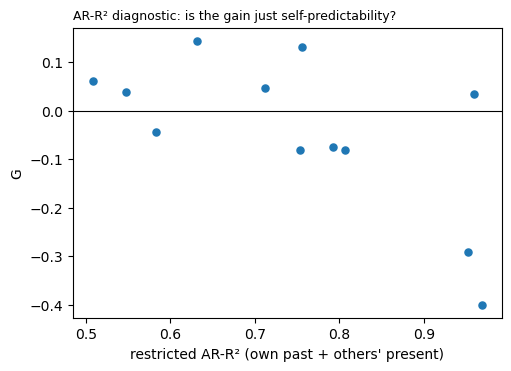

,source,target,G,null_mean,null_q95,z,p_emp
0,District_B,District_A,0.132,-0.001,0.088,2.205,0.010
1,District_C,District_A,-0.082,-0.033,0.043,-0.849,0.881
2,District_D,District_A,-0.075,-0.145,-0.031,1.226,0.129
3,District_A,District_B,-0.044,-0.034,0.004,-0.228,0.762
4,District_C,District_B,0.039,0.025,0.102,0.288,0.327
5,District_D,District_B,0.061,0.049,0.079,0.688,0.248
6,District_A,District_C,-0.080,-0.040,0.019,-0.578,0.901
7,District_B,District_C,0.144,-0.002,0.087,2.684,0.010
8,District_D,District_C,0.046,0.046,0.064,0.045,0.545
9,District_A,District_D,-0.400,-0.128,0.006,-1.054,0.921


,,forward,reversed
source,target,,
District_B,District_A,0.132,-0.174
District_C,District_A,-0.082,0.035
District_D,District_A,-0.075,-0.094
District_A,District_B,-0.044,-0.098
District_C,District_B,0.039,-0.020
District_D,District_B,0.061,0.063
District_A,District_C,-0.080,-0.095
District_B,District_C,0.144,-0.065
District_D,District_C,0.046,-0.030


In [5]:
CFG = TR.TransferCfg(p=1, min_train=4, lam=1e-2, control="mean",
                     control_time="both", feats=FEAT_COLS)

GM = TR.gain_matrix(PHI, CFG)
display(GM.pivot_table(index="source", columns="target", values="G").round(3))
display(TR.asymmetry(GM).round(3))

fig, ax = plt.subplots(figsize=(5, 3.6), layout="constrained")
ax.scatter(GM["r2_restricted"], GM["G"], s=26)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="restricted AR-R² (own past + others' present)", ylabel="G")
ax.set_title("AR-R² diagnostic: is the gain just self-predictability?", fontsize=9, loc="left")
plt.show()

NULLS = TR.null_matrix(PHI, CFG, n_surr=100, kind="permute", seed=0)
display(NULLS[["source", "target", "G", "null_mean", "null_q95", "z", "p_emp"]].round(3))
REG.report("transfer", "pairs clearing their capacity null",
           f"{int((NULLS['p_emp'] < 0.05).sum())}/{len(NULLS)}",
           "read against the null, not against 0")

REV = TR.gain_matrix(TR.reverse_blocks(PHI), CFG)
cmp = (GM.set_index(["source", "target"])["G"]
       .to_frame("forward").join(REV.set_index(["source", "target"])["G"]
                                 .to_frame("reversed")))
display(cmp.round(3))

### 4b. The three channel arms

`pure` channels see their own district; `mixed` channels see the neighbours hydraulically.
`G_mixed − G_pure` is the **hydraulic-exposure** claim, `G_pure` is the demand-dependence one,
and `G_all` against $\max(G_{\text{pure}}, G_{\text{mixed}})$ says whether the joint encoding is
mixing the two destructively — a statement about the AER, not about dependence. Requires the
decoded arm (the slot classes come from the sensor table).

In [6]:
if world is not None:
    ARM_TAB = TR.arm_table({k: v["phi_class"] for k, v in ARMS.items()
                            if k in ("pure", "mixed", "all")}, CFG)
    display(ARM_TAB.round(3))
else:
    print("needs the world (slot classes come from sensor_placement.csv)")

arm,source,target,all,mixed,pure,exposure(mixed-pure),all_minus_best
0,District_A,District_B,-0.215,-0.299,-0.044,-0.255,-0.171
1,District_A,District_C,-0.123,-0.093,-0.080,-0.012,-0.043
2,District_A,District_D,-0.347,-0.139,-0.400,0.261,-0.209
3,District_B,District_A,-0.009,-0.850,0.132,-0.981,-0.141
4,District_B,District_C,-0.037,-0.082,0.144,-0.226,-0.181
5,District_B,District_D,-0.117,-0.165,-0.291,0.126,0.049
6,District_C,District_A,-0.198,-0.626,-0.082,-0.544,-0.116
7,District_C,District_B,-0.069,-0.039,0.039,-0.078,-0.108
8,District_C,District_D,0.049,-0.067,0.035,-0.102,0.014
9,District_D,District_A,-0.507,-0.231,-0.075,-0.156,-0.432


## 5. Rolling gain, and where it peaks

$G(b)$ on a sliding training window, pooled over `smooth` blocks. The falsifiable prediction is
that a propagation signal **peaks inside the ramp**: under a uniform null the p-value is simply
`n_ramp_blocks / n_evaluated`, exact and cheap. A spurious signal has no reason to be timed
correctly, which is what makes this stronger than any static $G$ from ~20 blocks.

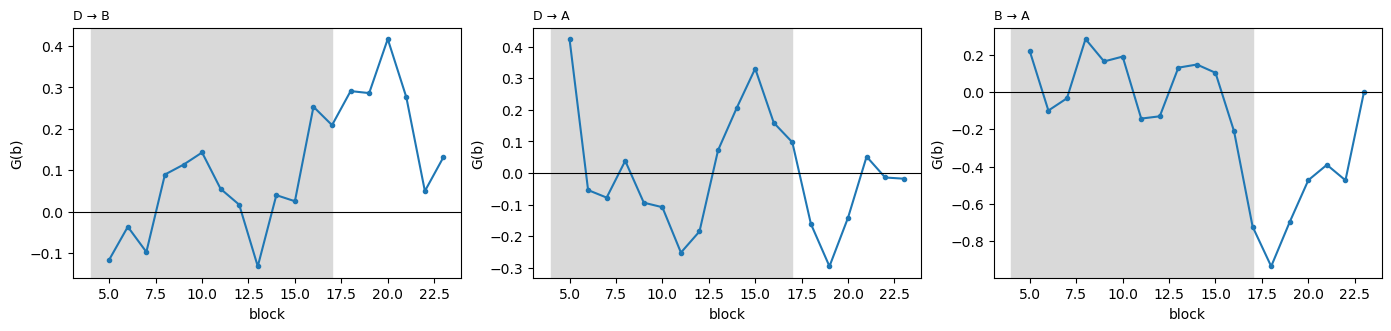

,peak_bid,in_ramp,G_peak,n_eval,n_ramp,p_uniform,source,target
0,20,False,0.416805,19,13,0.684211,District_D,District_B
1,5,True,0.423873,19,13,0.684211,District_D,District_A
2,8,True,0.283916,19,13,0.684211,District_B,District_A


In [7]:
RAMP = (PC.drift_ramp(world, BLOCK_MONTHS)["ramp_blocks"] if world is not None
        else sorted(WT.loc[WT["phase"] == "transition", "bid"].unique().tolist()))
PAIRS = TR.asymmetry(GM).sort_values("asym", key=abs, ascending=False).head(3)

fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.6 * len(PAIRS), 3.2),
                         squeeze=False, layout="constrained")
rows = []
for ax, r in zip(axes[0], PAIRS.itertuples(index=False)):
    src, tgt = (r.client_a, r.client_b) if r.G_a_to_b >= r.G_b_to_a else (r.client_b, r.client_a)
    gb = TR.rolling_gain(PHI, tgt, src, CFG, win=8, smooth=3)
    on = TR.onset_test(gb, RAMP); on.update(source=src, target=tgt); rows.append(on)
    ax.plot(gb["bid"], gb["G"], marker="o", ms=3)
    ax.axhline(0, color="k", lw=0.8)
    if RAMP:
        ax.axvspan(min(RAMP), max(RAMP), color="0.85", zorder=0)
    ax.set(xlabel="block", ylabel="G(b)")
    ax.set_title(f"{src[-1]} → {tgt[-1]}", fontsize=9, loc="left")
plt.show()
display(pd.DataFrame(rows))

## 6. Stage 4 — quantisation and the chain

The codebook is fitted on **init only** and frozen — the same frozen-ruler logic as the encoder —
and lives in shape space, because under a per-client MinMax the level is in each client's own
units and clustering on it clusters clients rather than regimes.

Then, in order of what can fail:

1. `codebook_stability` — ARI of half-sample refits. Low ARI and everything after this is
   codebook noise.
2. `markov_order_test` — if order 0 is not rejected there are no dynamics and the chain adds
   nothing over the occupancy histogram. This is the idea's real failure mode, so it is tested
   before anything is built on it.
3. `occupancy_matrix` — $1-\mathrm{JS}(\pi_c,\pi_d)/\log 2$. Unlike a cosine this does not divide
   out the norm, so magnitude survives on an ordinal ladder. Read init → final: the drifted
   client's pairs should fall.
4. `stationarity_split` — init should PASS (one regime) and transition should FAIL (the regime is
   moving). Read the transition counts first: halves of a short phase have no power.
5. `pair_table` — MI and both directions of TE, each with its plug-in bias printed next to it.
   **Nothing below the bias is a finding.**
6. Two nulls. `chain_null` resamples each client from its own fitted chain (preserves marginal
   dynamics, destroys cross-client alignment); `month_block_null` permutes whole months with
   their classes attached, which is the inference-correct one for a class-pooled estimate.
   Running both and reporting the gap is the honest version.

In [8]:
PHI_POOL = (ARMS[ARM]["phi_class"] if world is not None else ARMS["latent_pooled"]["phi"])
STAB = CH.codebook_stability(PHI_POOL, k=K_STATES, space="shape", seed=0)
print(STAB)
CB  = CH.fit_codebook(PHI_POOL, k=K_STATES, space="shape", fit_phase="init", seed=0)
SYM = CH.symbol_table(PHI_POOL, CB, seq_key="cycle_pos")

display(CH.markov_order_test(CH.sequences(SYM, sorted(SYM['client'].unique())[0]),
                             K_STATES).round(4))
display(pd.crosstab([SYM["client"], SYM["phase"]], SYM["s"], normalize="index").round(2))

OCC = pd.concat({ph: CH.occupancy_matrix(SYM, K_STATES, ph).set_index(["client_a", "client_b"])["sim"]
                 for ph in ("init", "transition", "final")}, axis=1)
display(OCC.round(3))

SPL = pd.DataFrame([CH.stationarity_split(SYM, K_STATES, c, ph)
                    for c in sorted(SYM["client"].unique())
                    for ph in ("init", "transition", "final")])
display(SPL[["client", "phase", "G2", "df", "p", "n_transitions"]].round(4))

c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\arthu\anaconda3\envs\TsLeaks\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.Cre

{'k': 3, 'ari_mean': 0.8833248525135593, 'ari_min': 0.728433640243036, 'distortion': 0.7414641545583298, 'n_rep': 10, 'stable': True}


,test,G2,df,p,reads
0,order 0 vs 1,196.7012,6,0.0000,reject = there ARE dynamics; not rejected = th...
1,order 1 vs 2,15.2659,12,0.2272,reject = order 1 is too short a memory


s                         0     1     2
client     phase                       
District_A final       0.60  0.12  0.29
           init        0.29  0.71  0.00
           transition  0.54  0.26  0.20
District_B final       0.21  0.48  0.31
           init        0.32  0.64  0.04
           transition  0.34  0.44  0.22
District_C final       0.00  0.71  0.29
           init        0.14  0.71  0.14
           transition  0.05  0.73  0.21
District_D final       0.29  0.57  0.14
           init        0.29  0.57  0.14
           transition  0.29  0.57  0.14

init  transition  final
client_a   client_b                            
District_A District_B  0.980       0.965  0.850
           District_C  0.911       0.742  0.532
           District_D  0.923       0.922  0.826
District_B District_C  0.948       0.888  0.875
           District_D  0.973       0.986  0.971
District_C District_D  0.977       0.922  0.834

,client,phase,G2,df,p,n_transitions
0,District_A,init,0.0000,6,1.0000,"{'first': 7.0, 'second': 7.0}"
1,District_A,transition,2.6060,6,0.8564,"{'first': 42.0, 'second': 42.0}"
2,District_A,final,5.1465,6,0.5252,"{'first': 14.0, 'second': 14.0}"
3,District_B,init,3.2557,6,0.7761,"{'first': 7.0, 'second': 7.0}"
4,District_B,transition,6.8365,6,0.3362,"{'first': 42.0, 'second': 42.0}"
5,District_B,final,4.1399,6,0.6578,"{'first': 14.0, 'second': 14.0}"
6,District_C,init,0.0000,6,1.0000,"{'first': 7.0, 'second': 7.0}"
7,District_C,transition,0.1396,6,0.9999,"{'first': 42.0, 'second': 42.0}"
8,District_C,final,0.0000,6,1.0000,"{'first': 14.0, 'second': 14.0}"
9,District_D,init,0.0000,6,1.0000,"{'first': 7.0, 'second': 7.0}"


In [9]:
PT = CH.pair_table(SYM, K_STATES)
display(PT.round(4))
REG.report("chain", "MI above bias", f"{int((PT['mi'] > PT['mi_bias']).sum())}/{len(PT)}")
REG.report("chain", "TE above bias",
           f"{int((PT[['te_a_to_b','te_b_to_a']].max(axis=1) > PT['te_bias']).sum())}/{len(PT)}")

NUL = []
for r in PT.itertuples(index=False):
    NUL.append(CH.month_block_null(SYM, K_STATES, r.client_a, r.client_b,
                                   n_rep=100, seed=0, stat="mi"))
    NUL.append(CH.chain_null(SYM, K_STATES, r.client_a, r.client_b,
                             n_rep=100, seed=0, stat="mi"))
display(pd.DataFrame(NUL)[["client_a", "client_b", "null", "value",
                           "null_mean", "null_q95", "p_emp"]].round(3))

,client_a,client_b,phase,n,mi,mi_bias,te_a_to_b,te_b_to_a,te_bias,te_asym,mi_above_bias
0,District_A,District_B,None,161,0.0698,0.0124,0.0579,0.0157,0.0373,0.0422,True
1,District_A,District_C,None,161,0.0671,0.0124,0.0122,0.0339,0.0373,-0.0217,True
2,District_A,District_D,None,161,0.1382,0.0124,0.0000,0.0643,0.0373,-0.0643,True
3,District_B,District_C,None,161,0.1149,0.0124,0.0236,0.0193,0.0373,0.0042,True
4,District_B,District_D,None,161,0.1926,0.0124,0.0000,0.0644,0.0373,-0.0644,True
5,District_C,District_D,None,161,0.3242,0.0124,0.0000,0.0594,0.0373,-0.0594,True


,client_a,client_b,null,value,null_mean,null_q95,p_emp
0,District_A,District_B,month blocks,0.070,0.001,0.013,0.010
1,District_A,District_B,fitted chains,0.070,0.029,0.069,0.059
2,District_A,District_C,month blocks,0.067,0.037,0.055,0.020
3,District_A,District_C,fitted chains,0.067,0.039,0.105,0.208
4,District_A,District_D,month blocks,0.138,0.130,0.138,0.248
5,District_A,District_D,fitted chains,0.138,0.106,0.269,0.248
6,District_B,District_C,month blocks,0.115,0.082,0.101,0.020
7,District_B,District_C,fitted chains,0.115,0.024,0.058,0.010
8,District_B,District_D,month blocks,0.193,0.174,0.185,0.059
9,District_B,District_D,fitted chains,0.193,0.046,0.112,0.010


## 7. Stage 5 — what survives conditioning

$\mathrm{pcorr}(c,d)=-\Theta_{cd}/\sqrt{\Theta_{cc}\Theta_{dd}}$ with
$\Theta=(R+\lambda I)^{-1}$. A similarity that vanishes once the other clients are held fixed was
the shared path, not dependence — which is the confound this project exists to fight.

**Read `condition_report` first.** With a dominant shared component the client correlation matrix
is near rank-1 and the partial correlations are not interpretable; the stage says so instead of
returning confident numbers. `shrinkage_path` is the second guard: a partial correlation whose
sign flips inside a sensible penalty range is not a finding. Adjacency is used for SCORING only.

In [10]:
PARTIAL_FEAT = "amp" if "amp" in FEAT_COLS else FEAT_COLS[0]   # amp survives a per-client scaler
X, CL = PD.client_matrix(PHI, PARTIAL_FEAT, seq_key="cycle_pos")
print("feature:", PARTIAL_FEAT)
COND = PD.condition_report(X, CL)
display(COND.to_frame().T)
REG.gate("partial", "precision matrix estimable", COND["verdict"],
         bool(COND["estimable"]), "above 100 do not read the partials")

MVP = PD.marginal_vs_partial(X, CL, lam=0.1)
display(MVP.round(3))
display(PD.shrinkage_path(X, CL).pivot_table(index=["client_a", "client_b"],
                                             columns="lam", values="partial_r").round(3))

if world is not None:
    ADJ, src = PC.district_adjacency(world)
    print("adjacency from:", src)
    display(PD.structural_contrast(MVP, ADJ).round(3))

feature: amp


,n_rows,n_clients,rows_per_parameter,cond_number,min_eigenvalue,verdict,estimable
0,168,4,42.0,21.985139,0.093024,ok,True


,client_a,client_b,lam,marginal_r,partial_r,drop
0,District_A,District_B,0.1,0.329,0.140,0.189
1,District_A,District_C,0.1,-0.016,-0.481,-0.464
2,District_A,District_D,0.1,0.511,0.603,-0.092
3,District_B,District_C,0.1,0.078,-0.073,0.005
4,District_B,District_D,0.1,0.305,0.161,0.144
5,District_C,District_D,0.1,0.738,0.765,-0.027


lam                     0.01   0.05   0.10   0.20   0.50
client_a   client_b                                     
District_A District_B  0.089  0.119  0.140  0.157  0.155
           District_C -0.638 -0.558 -0.481 -0.373 -0.212
           District_D  0.726  0.664  0.603  0.514  0.369
District_B District_C -0.112 -0.091 -0.073 -0.051 -0.022
           District_D  0.182  0.170  0.161  0.150  0.131
District_C District_D  0.858  0.814  0.765  0.685  0.526

adjacency from: network links (cross-district)


,signal,n_adjacent,n_other,mean_adjacent,mean_other,auc
0,marginal_r,3,3,0.285,0.374,0.444
1,partial_r,3,3,0.408,0.333,0.556


## 8. The factor study

Every estimator above is a **scorer over stored runs** — no GPU, no retraining. `score_grid`
tags each row with a `method_hash` of the estimator's own configuration, so re-scoring with a
changed estimator lands in new rows instead of pooling silently with the old ones.

Two constraints the module enforces rather than trusts: the grid is unbalanced by construction,
so `coverage` says which axes are estimable and `axis_effects` reports a direction with its cell
count and its spread across comparability blocks — never a balanced ANOVA; and cells may only be
differenced inside a comparability block.

In [11]:
def score_transfer(store, row):
    """One row per ordered pair, for one stored run."""
    t = GD.load_tables(row, tables=("latent_trajectories",))
    wt = TJ.latent_windows(t["latent_trajectories"], t["fl"]["preprocessing"],
                           t["meta"]["phases"], BLOCK_MONTHS, PERIOD_H, BIN_H)
    phi = TJ.latent_phi(wt, n_comp=2, basis="per_client")["phi"]
    cfg = TR.TransferCfg(p=1, min_train=4, lam=1e-2, control="mean",
                         control_time="both", feats=("z0", "z1"))
    gm = TR.gain_matrix(phi, cfg)
    gm["arm"] = "latent"
    return gm

PARAMS = dict(block_months=BLOCK_MONTHS, bin_h=BIN_H, n_comp=2,
              cfg="p1_mt4_l0.01_mean-both", arm="latent")
SCORES = GD.score_grid(None, IDX, score_transfer, "transfer_gain", PARAMS,
                       save=False, verbose=True)
SCORES = SCORES.merge(IDX[["run_key", "schedule", "proto_weight", "spec_term",
                           "cmp_block"]], on="run_key", how="left")
display(SCORES.groupby(["schedule", "proto_weight"])["G"]
        .agg(["mean", "max", "count"]).round(3))
display(GD.axis_effects(SCORES, "G", axes=("schedule", "proto_weight", "spec_term")))

[1/42] fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0__Lp0__C0-11 12 rows
[2/42] fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0__Lp0.1-s1__S6x129w10 12 rows
[3/42] fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0__Lp0.1-s1 12 rows
[4/42] fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0__Lp0 12 rows
[5/42] fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0__Lp0__S6x129w10 12 rows
[6/42] fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0__Lp0.1-s1__C0-11 12 rows
[7/42] fmp~b02f4f__none__minmax_ref__a3w84s12__u30r5s0  12 rows
[8/42] fpmp__none__minmax_ref__a3w84s12__u30r5s0        12 rows
[9/42] fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0.1-d1 12 rows
[10/42] fmp__none__minmax_ref__a3w84s4__u30r30e5s0__Lp0  12 rows
[11/42] fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0__Lp0.1-s1__C0-11 12 rows
[12/42] fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0__Lp0.1-d1 12 rows
[13/42] fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0   12 rows
[14/42] fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0__Lp0 12 rows
[15

mean    max  count
schedule      proto_weight                     
all           0.0          -0.036  0.132     84
              0.1          -0.053  0.279     84
              1.0          -0.133  0.143     24
commissioning 0.0          -0.215  0.094     48
              0.1          -0.099  0.086     48
              1.0          -0.055  0.216     12
streaming     0.0          -0.157  0.372     48
              0.1          -0.091  0.170     48
              1.0          -0.016  0.197     12

,axis,level,mean,spread_across_blocks,n_cells,n_blocks
0,proto_weight,1.0,-0.051082,0.093934,48,2
1,proto_weight,0.1,-0.067306,0.056167,180,4
2,proto_weight,0.0,-0.084615,0.090448,180,5
3,schedule,all,-0.051191,0.068575,288,7
4,schedule,streaming,-0.090787,0.056846,108,3
5,schedule,commissioning,-0.124532,0.061782,108,3
6,spec_term,1.0,-0.064371,0.050424,192,4
7,spec_term,0.0,-0.085472,0.089490,216,5


## 9. The register

Every check, with its verdict, in one frame — and `selfcheck` run against the same store, so the
estimators' own behaviour (the protocol contract, the nulls, the preconditions) is recorded next
to the results they produced.

In [12]:
SC_OUT = SC.check_run(FOCUS, block_months=BLOCK_MONTHS, bin_h=BIN_H,
                      period_h=PERIOD_H, k=K_STATES, reg=Register("selfcheck"))
display(SC_OUT["reg"].frame())
REG.extend(SC_OUT["reg"])
display(REG.frame())
print(REG)
print("closed gates (results that restrict what may be read -- not errors):")
display(REG.gates(open_=False)[["stage", "check", "value", "note"]])
REG.assert_all()          # raises only on failed INTEGRITY checks

,stage,kind,check,value,passed,note
0,run,report,cell,fmp__none+or__minmax_ref__a3w84s4__u30r142e5s0...,None,ky72 · spectral · drift District_A
1,calendar,check,native resolution recovered (h),1.0,True,step_size x interval_agg_h / median diff(windo...
2,calendar,report,cycle classes,7,None,"period 168 h, bin 24"
3,calendar,report,blocks per phase,"{'final': 6, 'init': 4, 'transition': 14}",None,block = 3 months
4,calendar,check,occupancy floor (windows per prototype),4,True,below the floor a prototype IS one window -- t...
5,contract,check,month-mean latents == post_fedavg_full,0.0,True,the trajectory is the artifact the protocol ex...
6,transfer,report,restricted AR-R^2 per target,"{'District_A': 0.893, 'District_B': 0.92, 'Dis...",None,"if G tracks this across targets, the asymmetry..."
7,transfer,report,G range,"(-1.488, 0.086)",None,negative = the source bought nothing out of sa...
8,transfer,check,capacity null is usable,"{'G': 0.086, 'null_mean': 0.092, 'null_q95': 0...",True,a null far from 0 means G must be read against...
9,transfer,report,time reversal (best pair),"{'forward': 0.086, 'reversed': 0.168}",None,propagation weakens or inverts; a variance art...


,stage,kind,check,value,passed,note
0,env,check,Intel OpenMP runtimes loaded,2,False,two = torch's + MKL's: the OMP Error #15 condi...
1,env,report,MKL threading layer,[sequential],None,should read 'sequential'
2,grid,report,cells pulled,42,None,7 comparability block(s)
3,stage0,report,world,District_A__LR_LR_LC_LI__baseline,None,ky72 / spectral / dynamic
4,stage0,report,months per phase,"{'init': 12, 'transition': 41, 'final': 17}",None,
5,stage0,gate,blocks in transition (block_months=3),14,True,rolling G needs >= 8
6,stage0,report,ramp blocks,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...",None,"span months (12, 53)"
7,stage0,gate,chain budget at k=3,168,True,blocks x classes against c_cell k^2; classes a...
8,stage0,check,channels per client equal,"{'District_A': 4, 'District_B': 4, 'District_C...",True,unequal D_m is a size confound
9,stage0,gate,active storage exchange (lag arm),"{'n_tanks': 3, 'n_active': 1, 'active_tanks': ...",True,open = at least one tank fills and drains; whi...


Register('POC_05', rows=36, checks=6, failed=1, gates=7, closed=1)
closed gates (results that restrict what may be read -- not errors):


,stage,check,value,note
33,partial,precision matrix is estimable,"{'rows/par': 42.0, 'cond': 137.3, 'verdict': '...",above 100 the partial correlations are not int...


AssertionError: 1 sanity check(s) failed:
  [env] Intel OpenMP runtimes loaded: 2  (two = torch's + MKL's: the OMP Error #15 condition)

## What to read out of this

* **Is the lag arm open?** §2's storage-exchange numbers decide whether window-scale directional
  work is even defined on this world. If it is closed, the only directional mechanism is
  month-scale drift propagation and §4–§5 are the whole causal story.
* **Does $G$ track `r2_restricted`?** If it does, the asymmetry is self-predictability on this
  world and the direction claim dies here — measured, not inherited.
* **Does $G(b)$ peak inside the ramp?** That is the strongest available claim from a horizon this
  short, because the timing is hard to hit by accident.
* **Is TE above its bias?** $k(k-1)^2/2N$ nats. Below it, the number is the estimator, not the
  world.
* **How much of MI is the calendar?** The gap between the raw MI and the month-block null mean.
* **Is the precision matrix interpretable at all?** If the condition number says no, Stage 5
  reports that instead of a partial correlation — a refusal is a result.
* **Honest n.** One world, one seed, six pairs. Every axis effect in §8 is a direction until it
  is repeated across worlds and seeds.